# AUTOCORRELATION

#### We know that in time series we avoid suffling data because we want to preserve the cronological order and one of the main reason for that is we often discovered the link between past and present values in t-series data

#### --we know that correlation between (x,y) measures the singularity in the change of values of two series
### --but here we only have single variable so we have to discover a new concept **AUTOCORRELATION** 

### **AUTOCORRELATION** -- The correlation between a sequence and itself

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()
raw_csv_data=pd.read_csv("Index2018.csv")
df_comp=raw_csv_data.copy()
df_comp.date=pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date",inplace=True)
df_comp=df_comp.asfreq("b")
df_comp=df_comp.ffill()
df_comp['market_value']=df_comp.spx
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size=int(len(df_comp)*0.8)
df=df_comp.iloc[:size]
df_test=df_comp.iloc[size:]
wn=np.random.normal(loc=df.market_value.mean(),scale=df.market_value.std(),size=len(df))
df['wn']=wn
rw=pd.read_csv("Randwalk.csv")
rw.date=pd.to_datetime(rw.date, dayfirst=True)
rw.set_index("date",inplace=True)
rw=rw.asfreq('b')
rw.describe()
df['rw']=rw.price

C:\Users\ysriv\AppData\Local\Temp\ipykernel_39748\3873343694.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn']=wn
C:\Users\ysriv\AppData\Local\Temp\ipykernel_39748\3873343694.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rw']=rw.price


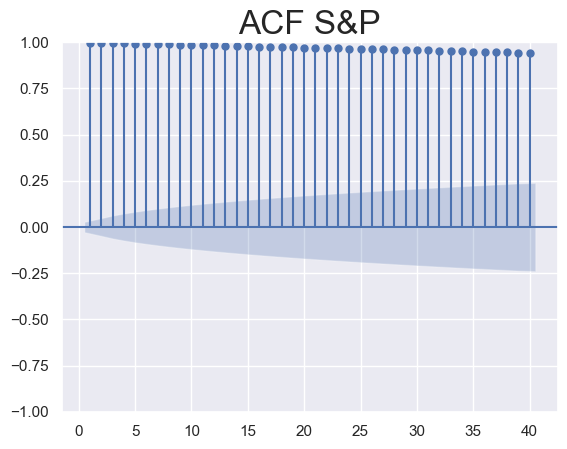

In [ ]:
# for Autocorrelation we have to introduce Autocorrelation function and plot the graph
# plottin the ACF graph of market value
sgt.plot_acf(df.market_value, lags = 40, zero=False)
plt.title("ACF S&P",size=24)
plt.show()

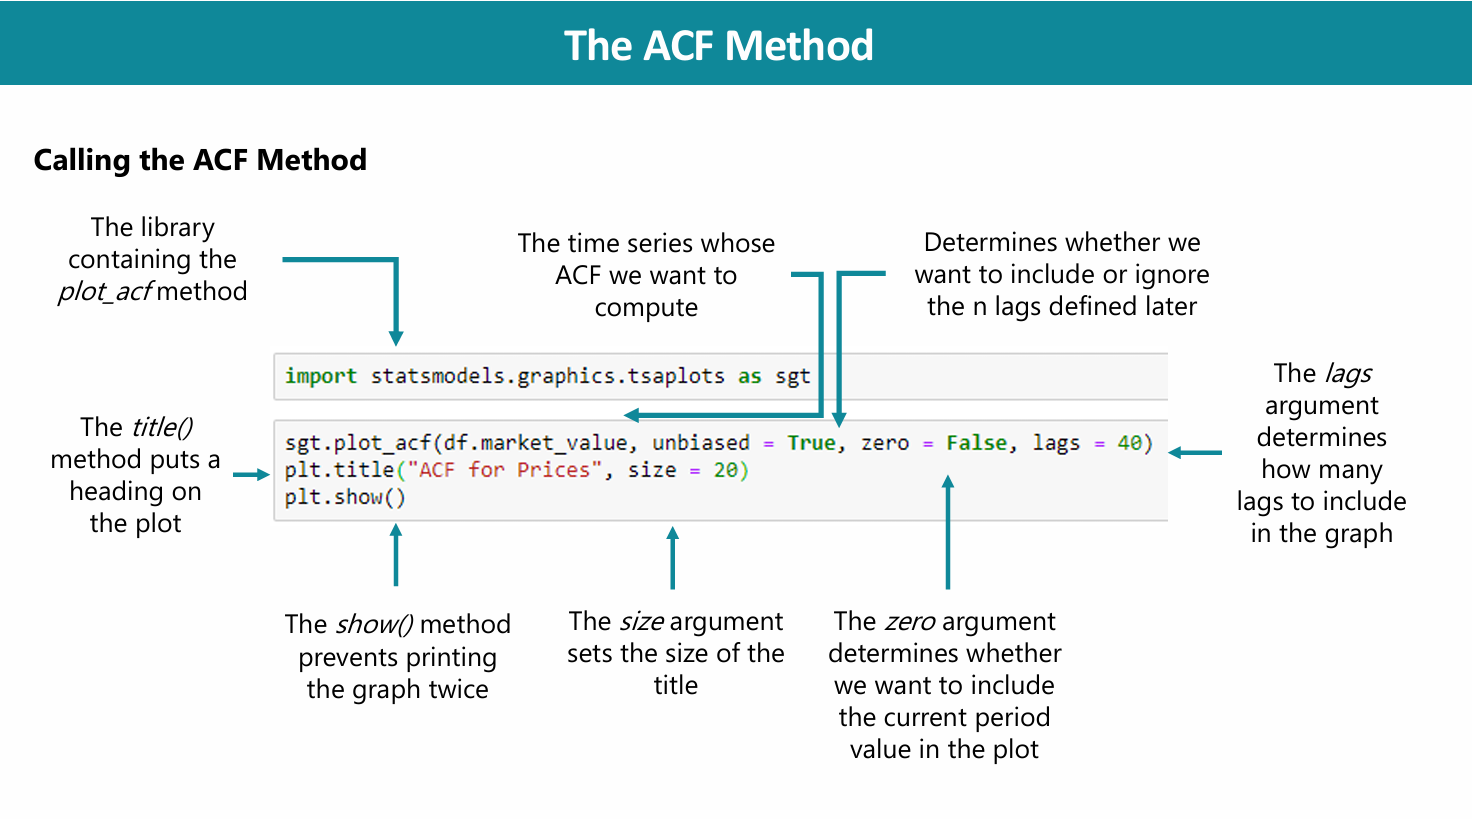

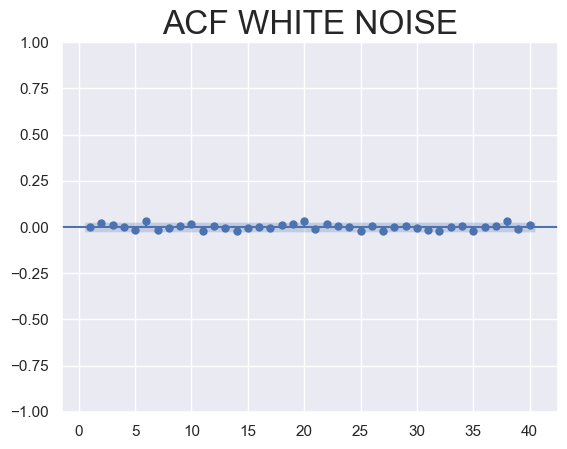

In [5]:
# ACF graph for white noise
sgt.plot_acf(df.wn, lags = 40, zero=False)
plt.title("ACF WHITE NOISE",size=24)
plt.show()

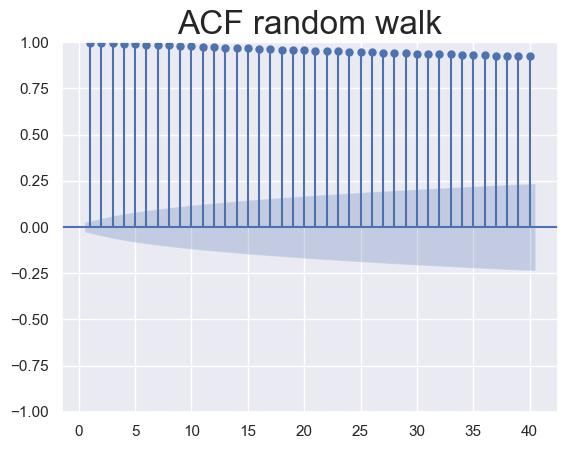

In [8]:
# ACF for random walk
sgt.plot_acf(df.rw, lags = 40, zero=False)
plt.title("ACF random walk",size=24)
plt.show()

# --------------------------------------------------------------------------

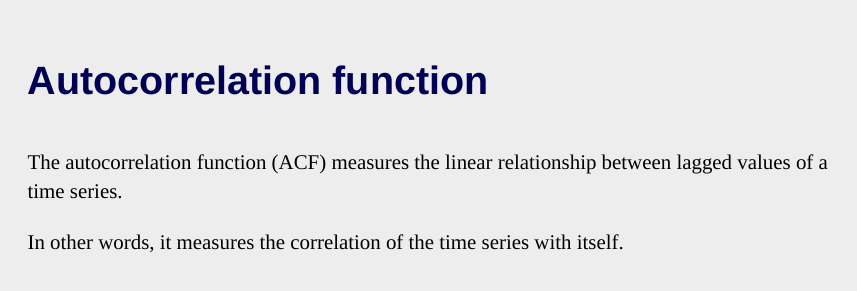

## For example, we can calculate the autocorrelation coefficient between yt and yt–1. In this case, the lag is equal to 1, and the coefficient would be denoted as r1. Similarly, we can calculate the autocorrelation between yt and yt–2. Then the lag would be 2, and the coefficient would be denoted as r2. When we plot the ACF function, the coefficient is the dependent variable, while the lag is the independent variable. Note that the autocorrelation coefficient at lag 0 will always be equal to 1. This makes sense intuitively, because the linear relationship between a variable and itself at the same timestep should be perfect, and therefore equal to 1.In the presence of a trend, a plot of the ACF will show that the coefficients are high for short lags, and they will decrease linearly as the lag increases. If the data is seasonal, the ACF plot will also display cyclical patterns.Therefore, plotting the ACF function of a non-stationary process will not give us more information than is available by looking at the evolution of our process through time. However, plotting the ACF for a stationary process can help us identify the presence of a random walk.